In [1]:
# Cell 1: Mount Google Drive and Verify Hardware
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Check the allocated GPU (Ensure you requested a T4 GPU under Runtime -> Change runtime type)
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Allocated GPU: {torch.cuda.get_device_name(0)}")

# 3. Create a fast local directory on Colab's SSD (much faster than training directly off Drive)
!mkdir -p /content/dataset


Mounted at /content/drive
CUDA Available: True
Allocated GPU: Tesla T4


In [2]:
# Cell 2: Unzip the Dataset to Local Storage
print("Extracting dataset from Google Drive to Colab local SSD...")

# Unzipping directly to /content/dataset/ for blazing fast I/O speeds
!unzip -q "/content/drive/My Drive/global_dataset_yolo.zip" -d "/content/dataset/"

print("Extraction complete. Verifying file structure:")
!ls -la /content/dataset/global_dataset/


Extracting dataset from Google Drive to Colab local SSD...
Extraction complete. Verifying file structure:
total 20
drwxr-xr-x 4 root root 4096 Mar  9 18:24 .
drwxr-xr-x 3 root root 4096 Mar  9 18:24 ..
-rw-r--r-- 1 root root  395 Mar  9 17:46 data.yaml
drw-r--r-- 4 root root 4096 Mar  9 18:12 test
drw-r--r-- 4 root root 4096 Mar  9 18:12 train


In [3]:
# Cell 3: Update `data.yaml` paths for the Colab Environment
import yaml

yaml_path = '/content/dataset/global_dataset/data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Hardcode the strict absolute paths for Colab's filesystem
data['train'] = '/content/dataset/global_dataset/train/images'
data['val'] = '/content/dataset/global_dataset/test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print("data.yaml paths successfully updated for Colab environment:")
!cat /content/dataset/global_dataset/data.yaml


data.yaml paths successfully updated for Colab environment:
names:
- garbage
- garbage_overflow
- manhole_broken
- manhole_lose
- manhole_uncovered
- pothole
- fallen_tree
nc: 7
test: c:\Users\devgu\OneDrive\Desktop\Yolo26_Pot_Garb_Tree_Manhole\global_dataset\test
train: /content/dataset/global_dataset/train/images
val: /content/dataset/global_dataset/test/images


In [4]:
# Cell 4: Install YOLO26 Dependencies
!pip install ultralytics

from IPython.display import clear_output
clear_output()

import ultralytics
ultralytics.checks()
print("Ultralytics successfully installed. Ready for training!")


Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 48.0/112.6 GB disk)
Ultralytics successfully installed. Ready for training!


In [5]:
import os
import glob
from ultralytics import YOLO
from IPython.display import Image, display
import yaml

# Define paths
test_images_dir = '/content/dataset/global_dataset/test/images'
test_labels_dir = '/content/dataset/global_dataset/test/labels'

# Load class names from data.yaml (already loaded in `data` variable)
# If `data` variable wasn't available, we would reload it:
# with open('/content/dataset/global_dataset/data.yaml', 'r') as f:
#     data = yaml.safe_load(f)
class_names = data['names']
num_classes = len(class_names)

print(f"Found {num_classes} classes: {class_names}")

# Collect one example image path for each class
example_images = {name: None for name in class_names}

# Iterate through label files to find examples
for label_file in glob.glob(os.path.join(test_labels_dir, '*.txt')):
    with open(label_file, 'r') as f:
        first_line = f.readline().strip()
        if first_line:
            class_id = int(first_line.split(' ')[0])
            class_name = class_names[class_id]
            if example_images[class_name] is None:
                # Construct image path from label file name
                image_name = os.path.basename(label_file).replace('.txt', '.jpg')
                image_path = os.path.join(test_images_dir, image_name)
                if os.path.exists(image_path):
                    example_images[class_name] = image_path
                else:
                    # Try .png if .jpg doesn't exist
                    image_name = os.path.basename(label_file).replace('.txt', '.png')
                    image_path = os.path.join(test_images_dir, image_name)
                    if os.path.exists(image_path):
                         example_images[class_name] = image_path

# Filter out classes for which no example image was found
example_images = {k: v for k, v in example_images.items() if v is not None}

print(f"\nFound example images for {len(example_images)} out of {num_classes} classes:")
for class_name, img_path in example_images.items():
    print(f"  {class_name}: {img_path}")

if not example_images:
    print("Warning: No example images found for any class in the test dataset.")


Found 7 classes: ['garbage', 'garbage_overflow', 'manhole_broken', 'manhole_lose', 'manhole_uncovered', 'pothole', 'fallen_tree']

Found example images for 7 out of 7 classes:
  garbage: /content/dataset/global_dataset/test/images/garbage_det_pile_147.jpg
  garbage_overflow: /content/dataset/global_dataset/test/images/garbage_over_Garbage_bin_00094.jpg
  manhole_broken: /content/dataset/global_dataset/test/images/manhole_cover_mh_000224.jpg
  manhole_lose: /content/dataset/global_dataset/test/images/manhole_cover_mh_000239.jpg
  manhole_uncovered: /content/dataset/global_dataset/test/images/manhole_cover_mh_000035.jpg
  pothole: /content/dataset/global_dataset/test/images/Pothole_ph_000476.jpg
  fallen_tree: /content/dataset/global_dataset/test/images/fallen_tree_ft_000136.jpg


In [6]:
from ultralytics import YOLO
from google.colab import files

# 1. Load the base model yolo26n.pt
model = YOLO('yolo26n.pt')

# 2-5. Retrain using the full dataset with specified parameters
results = model.train(
    data='/content/dataset/global_dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    fraction=1.0,
    cache=True,
    name='yolo26n_full_dataset',
    workers=2,
    amp=True
)

print("Training complete. Starting download of the best model weights...")

# Path to the best weights from this specific training run
best_model_path = 'runs/detect/yolo26n_full_dataset/weights/best.pt'

# Download to local computer
files.download(best_model_path)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/global_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_full_dataset, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Calculating metrics (mAP, Recall, etc.) on the test set...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 53.2±69.5 MB/s, size: 185.4 KB)
val: Scanning /content/dataset/global_dataset/test/labels.cache... 1092 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1092/1092 286.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 3.6it/s 18.9s
                   all       1092       1832      0.815      0.737      0.813      0.551
               garbage         42         45      0.828      0.667       0.74      0.437
      garbage_overflow         31         49      0.755      0.692      0.734      0.401
        manhole_broken         34         34      0.789       0.77      0.841      0.666
          manhole_lose         72         72      0.773    

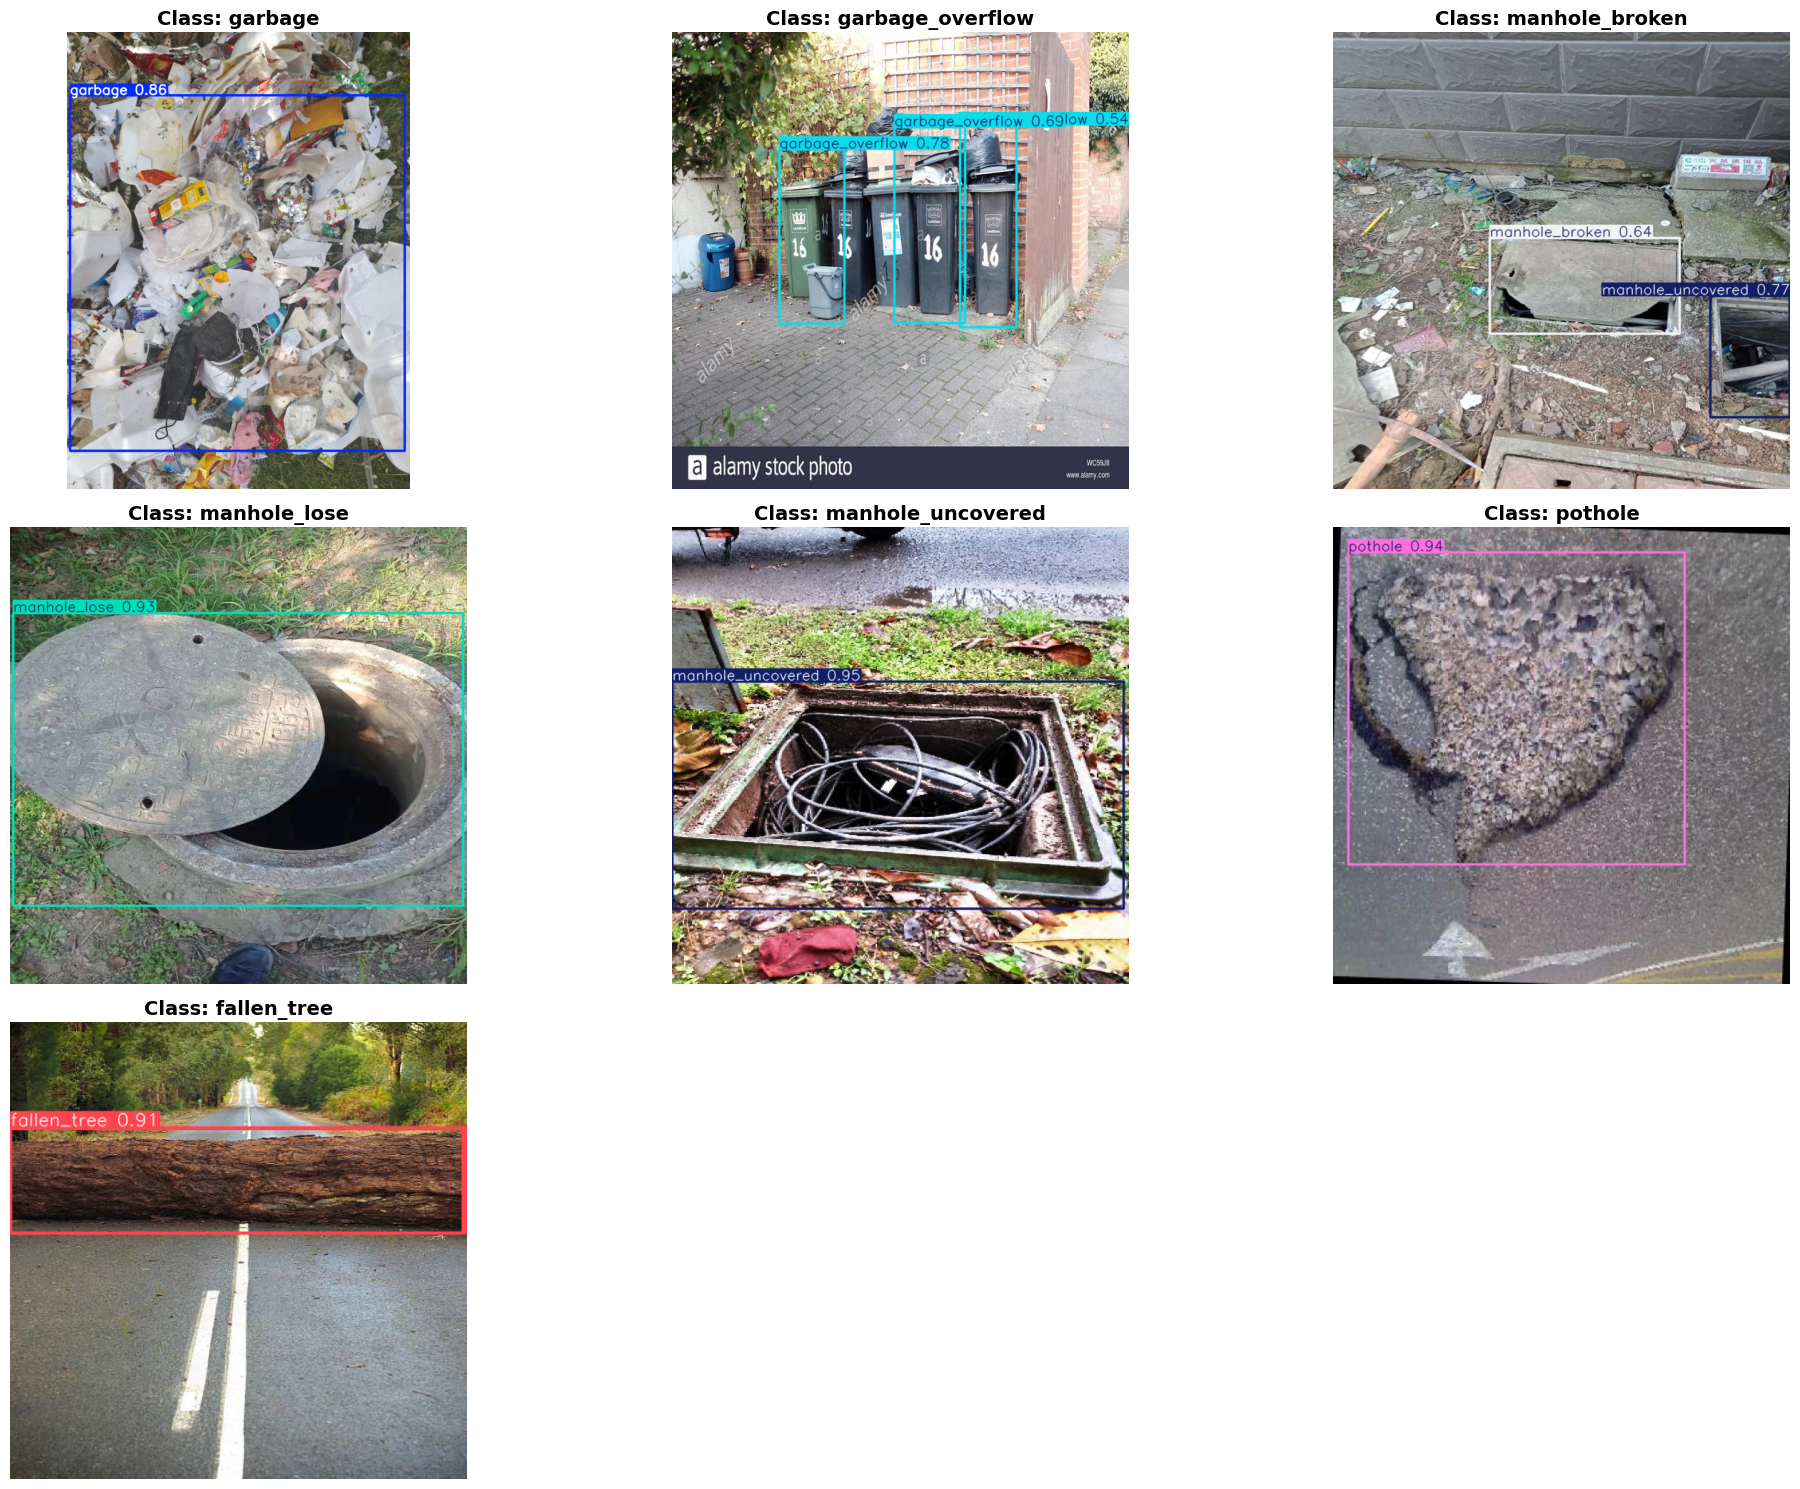

In [7]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# 1. Load the best trained model
# Note: Using the path where training saved the weights
model_path = '/content/runs/detect/yolo26n_full_dataset/weights/best.pt'
model = YOLO(model_path)

# 2. Run validation on the test set to get metrics
print("Calculating metrics (mAP, Recall, etc.) on the test set...")
metrics = model.val(data='/content/dataset/global_dataset/data.yaml', split='val')

# Print detailed metrics for each class
print("\nClass-wise Metrics:")
for i, name in enumerate(class_names):
    p = metrics.class_result(i)[0] # precision
    r = metrics.class_result(i)[1] # recall
    map50 = metrics.class_result(i)[2] # mAP50
    print(f"Class: {name:<20} | Precision: {p:.4f} | Recall: {r:.4f} | mAP50: {map50:.4f}")

# 3. Show detections on one image from each class
print("\nGenerating detections for example images...")

plt.figure(figsize=(20, 15))
for i, (name, img_path) in enumerate(example_images.items()):
    # Run inference
    results = model.predict(source=img_path, conf=0.25, save=False)

    # Plot the result using the plot() method which includes boxes and labels
    res_plotted = results[0].plot()

    # Convert BGR to RGB for matplotlib
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(res_rgb)
    plt.title(f"Class: {name}", fontsize=14, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO
from google.colab import files

# 1. Load the base model yolo26n.pt
model = YOLO('yolo26s.pt')

# 2-5. Retrain using the full dataset with specified parameters
results = model.train(
    data='/content/dataset/global_dataset/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    fraction=1.0,
    cache=True,
    name='yolo26n_full_dataset',
    workers=2,
    amp=True
)

print("Training complete. Starting download of the best model weights...")

# Path to the best weights from this specific training run
best_model_path = 'runs/detect/yolo26s_full_dataset/weights/best.pt'

# Download to local computer
files.download(best_model_path)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/global_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_full_dataset3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# 1. Load the best trained model
# Note: Using the path where training saved the weights
model_path = '/content/runs/detect/yolo26s_full_dataset/weights/best.pt'
model = YOLO(model_path)

# 2. Run validation on the test set to get metrics
print("Calculating metrics (mAP, Recall, etc.) on the test set...")
metrics = model.val(data='/content/dataset/global_dataset/data.yaml', split='val')

# Print detailed metrics for each class
print("\nClass-wise Metrics:")
for i, name in enumerate(class_names):
    p = metrics.class_result(i)[0] # precision
    r = metrics.class_result(i)[1] # recall
    map50 = metrics.class_result(i)[2] # mAP50
    print(f"Class: {name:<20} | Precision: {p:.4f} | Recall: {r:.4f} | mAP50: {map50:.4f}")

# 3. Show detections on one image from each class
print("\nGenerating detections for example images...")

plt.figure(figsize=(20, 15))
for i, (name, img_path) in enumerate(example_images.items()):
    # Run inference
    results = model.predict(source=img_path, conf=0.25, save=False)

    # Plot the result using the plot() method which includes boxes and labels
    res_plotted = results[0].plot()

    # Convert BGR to RGB for matplotlib
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(res_rgb)
    plt.title(f"Class: {name}", fontsize=14, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()